In [6]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [56]:
# Get the directory where the current file (util.py) is located
BASE_DIR = Path.cwd()

# .parent moves up to 'Cyber Project', then we navigate down to the json file
LOG_FILE = BASE_DIR / "json_logs" / "logs_argon2id_lockout_passwordspraying.json"

In [57]:
# Load the JSON logs
data = []
with open(LOG_FILE, 'r') as f:
    for line in f:
        data.append(json.loads(line))

In [58]:
df = pd.DataFrame(data)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['latency_ms'] = pd.to_numeric(df['latency_ms'])

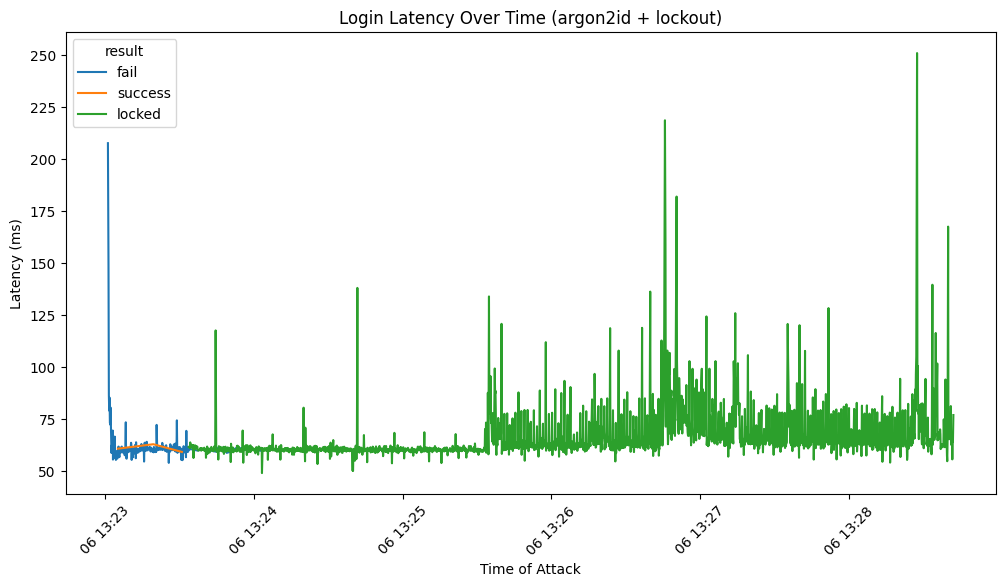

In [63]:
# 1. Latency Over Time (Detecting Resource Strain)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='timestamp', y='latency_ms', hue='result')
plt.title('Login Latency Over Time (argon2id + lockout)')
plt.ylabel('Latency (ms)')
plt.xlabel('Time of Attack')
plt.xticks(rotation=45)
plt.show()

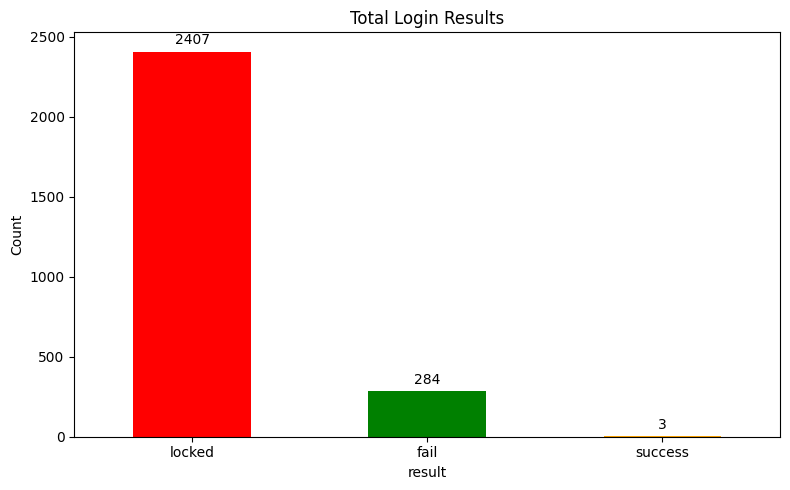

In [61]:
# 2. Success vs Failure Count with Numerical Labels
plt.figure(figsize=(8, 5))
counts = df['result'].value_counts()

# Create the plot and capture the axes (ax)
ax = counts.plot(kind='bar', color=['red', 'green', 'orange'])

plt.title('Total Login Results')
plt.ylabel('Count')
plt.xticks(rotation=0) # Keeps labels horizontal for readability

# --- OPTION 1: For Matplotlib 3.4+ (Modern & Easy) ---
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.savefig('login_results_with_labels.png')

/var/folders/28/pmh07v693dn2c3l0jdz5zvlw0000gn/T/ipykernel_20766/3148177807.py:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  rps_series = df.set_index('timestamp').resample('1S').size()


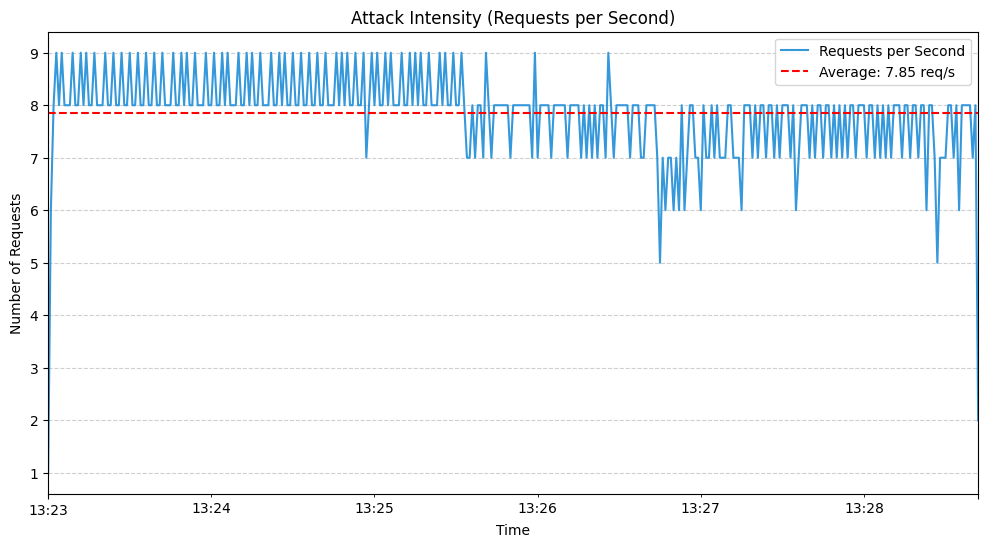

In [64]:
# 3. Request Frequency with Average Line
plt.figure(figsize=(12, 6))

# Resample by 1 second and count requests
rps_series = df.set_index('timestamp').resample('1S').size()
avg_rps = rps_series.mean()

# Plot the real-time frequency
rps_series.plot(kind='line', label='Requests per Second', color='#3498db')

# Add the average line
plt.axhline(y=avg_rps, color='r', linestyle='--', label=f'Average: {avg_rps:.2f} req/s')

plt.title('Attack Intensity (Requests per Second)')
plt.ylabel('Number of Requests')
plt.xlabel('Time')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

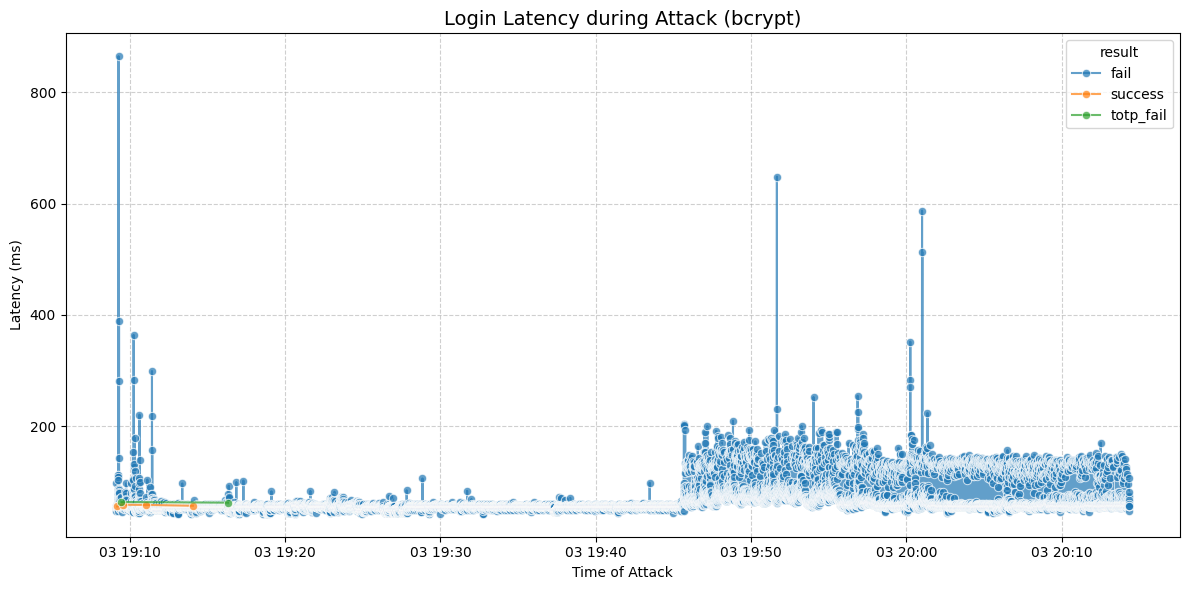

In [50]:
# Set the size of the plot for better readability
plt.figure(figsize=(12, 6))

# Use Seaborn's lineplot to map time to the X-axis and latency to the Y-axis
# The 'hue' parameter is critical: it creates separate colored lines for 'fail' and 'success'
sns.lineplot(
    data=df, 
    x='timestamp', 
    y='latency_ms', 
    hue='result', 
    marker='o',      # Adds dots at each data point
    alpha=0.7        # Makes lines slightly transparent to see overlaps
)

# Formatting the chart
plt.title('Login Latency during Attack (bcrypt)', fontsize=14)
plt.ylabel('Latency (ms)')
plt.xlabel('Time of Attack')
plt.grid(True, linestyle='--', alpha=0.6) # Adds a dashed grid for easier reading
plt.tight_layout()

# Save the plot
plt.savefig('latency_over_time.png')